In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
USE_SYNTHETIC = True   #  Change to False if you want to use CSV

In [21]:
# Load dataset
if USE_SYNTHETIC:
    # Import generator
    from synthetic_data_generator import generate_dataset

    df = generate_dataset()
    print("Synthetic Dataset Generated\n")

else:
    try:
        df = pd.read_csv("../Dataset/ai_impact_dataset.csv")
        print("Dataset Loaded Successfully\n")
    except FileNotFoundError:
        print("Error: Dataset file not found.")
        exit()

print(df.head())

Synthetic Dataset Generated

     Scenario  Concept_Score  Completion_Rate  Study_Time  Retention  \
0  Without_AI             65               71          51         62   
1  Without_AI             68               73          53         65   
2  Without_AI             66               71          52         63   
3  Without_AI             60               66          50         57   
4  Without_AI             59               64          49         56   

   Engagement  Teacher_Time  Feedback_Speed  
0         2.9           6.2              51  
1         2.6           5.8              52  
2         3.1           6.5              50  
3         2.8           6.2              53  
4         2.3           5.8              47  


In [22]:
# Ensure only numeric columns are used for calculations
numeric_cols = df.select_dtypes(include='number').columns

In [23]:
# Group by scenario
summary = df.groupby("Scenario")[numeric_cols].mean().round(2)

In [24]:
print("\n===== Average Impact Analysis =====")
print(summary)



===== Average Impact Analysis =====
            Concept_Score  Completion_Rate  Study_Time  Retention  Engagement  \
Scenario                                                                        
With_AI             81.87            92.40        27.9      78.17        4.22   
Without_AI          63.37            68.87        49.9      59.97        2.67   

            Teacher_Time  Feedback_Speed  
Scenario                                  
With_AI             1.98            3.93  
Without_AI          6.06           50.13  


In [25]:
# Calculate improvements
improvement = ((summary.loc["With_AI"] - summary.loc["Without_AI"]) / summary.loc["Without_AI"]) * 100

In [26]:
# Calculate percentage improvement
improvement = (
    (summary.loc["With_AI"] - summary.loc["Without_AI"])
    / summary.loc["Without_AI"]
) * 100

In [27]:
# Efficiency Score (custom metric)
summary["Efficiency_Score"] = (
    summary["Concept_Score"] * 0.25 +
    summary["Completion_Rate"] * 0.25 +
    summary["Retention"] * 0.2 +
    summary["Engagement"] * 0.1 -
    summary["Study_Time"] * 0.1 -
    summary["Teacher_Time"] * 0.1
)

In [28]:
improvement = improvement.round(2)

In [29]:
# efficiency score

summary["Efficiency_Score"] = (
    summary["Concept_Score"] * 0.25 +
    summary["Completion_Rate"] * 0.25 +
    summary["Retention"] * 0.2 +
    summary["Engagement"] * 0.1 -
    summary["Study_Time"] * 0.1 -
    summary["Teacher_Time"] * 0.1
).round(2)

print("\n===== Efficiency Score =====")
print(summary["Efficiency_Score"])


===== Efficiency Score =====
Scenario
With_AI       56.64
Without_AI    39.72
Name: Efficiency_Score, dtype: float64


<Figure size 640x480 with 0 Axes>

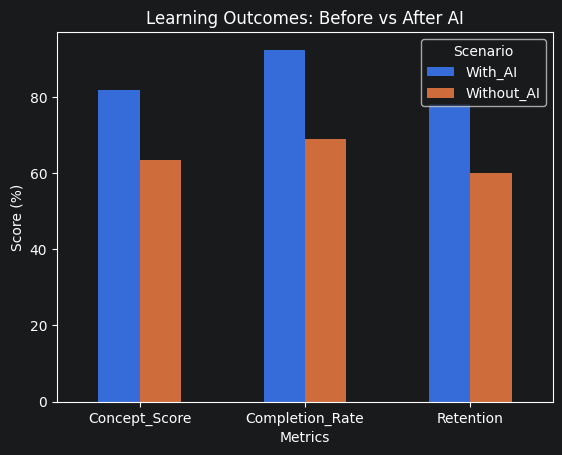

In [30]:
# 1. Learning Improvement Graph
plt.figure()
summary[["Concept_Score", "Completion_Rate", "Retention"]].T.plot(kind="bar")
plt.title("Learning Outcomes: Before vs After AI")
plt.ylabel("Score (%)")
plt.xlabel("Metrics")
plt.xticks(rotation=0)
plt.show()

<Figure size 640x480 with 0 Axes>

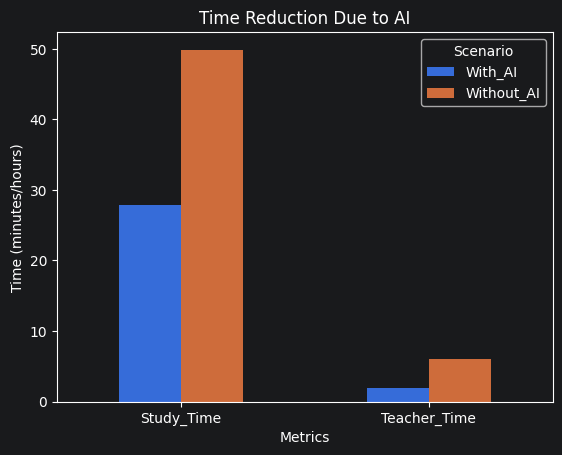

In [31]:
# 2. Time Reduction Graph
plt.figure()
summary[["Study_Time", "Teacher_Time"]].T.plot(kind="bar")
plt.title("Time Reduction Due to AI")
plt.ylabel("Time (minutes/hours)")
plt.xlabel("Metrics")
plt.xticks(rotation=0)
plt.show()

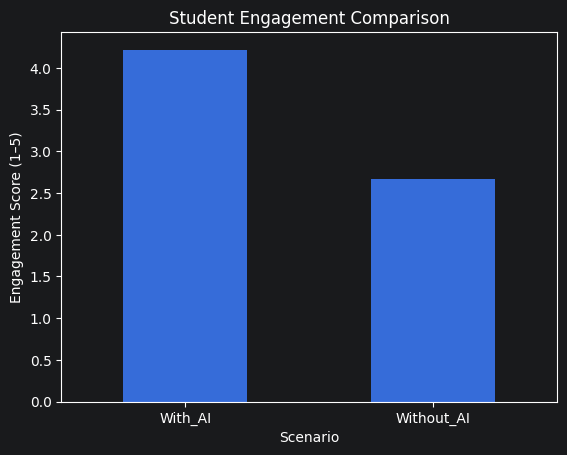

In [32]:
# 3. Engagement Improvement
plt.figure()
summary["Engagement"].plot(kind="bar")
plt.title("Student Engagement Comparison")
plt.ylabel("Engagement Score (1–5)")
plt.xticks(rotation=0)
plt.show()

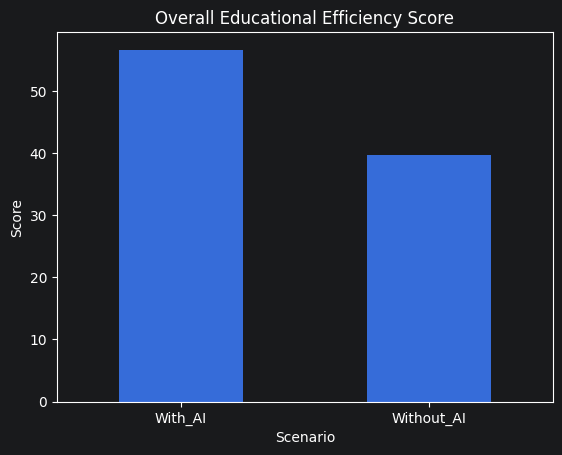

In [33]:
# 4. Efficiency Score Comparison
plt.figure()
summary["Efficiency_Score"].plot(kind="bar")
plt.title("Overall Educational Efficiency Score")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [34]:
if summary.loc["With_AI", "Efficiency_Score"] > summary.loc["Without_AI", "Efficiency_Score"]:
    print("\nConclusion: AI significantly improves overall educational efficiency.")
else:
    print("\nConclusion: AI shows limited impact.")


Conclusion: AI significantly improves overall educational efficiency.
